# HEART RATE ESTIMATION

Seismocardiography([SCG](https://www.ncbi.nlm.nih.gov/pubmed/24111357)) is a very promising technique to measure Heart Rate (HR) and Respiratory Rate (RR) with the detector positioned above sternum. It is generally based on accelerometer and gyroscope readings or a combination of them. 

Ballistocardiography([BCG](https://en.wikipedia.org/wiki/Ballistocardiography)) is an another technique to estimate heart and respiratory rate with combination of both accelerometer and gyroscope. It is an indirect evaluation of HR and RR since the contact between the device and the body of the subject is not required (e.g., accelerometer platform mounted under the slats of the bed).   
  
MuSe(Multi-Sensor miniaturized, low-power, wireless [IMU](https://en.wikipedia.org/wiki/Inertial_measurement_unit)) is an Inertial Measurement Unit (IMU) provide by [221e](https://www.221e.com). In the context of this project, It allows to record the inertial data necessary for the estimation of SCG and BCG.

The goal of this assignment is to estimate the heart rate of an healthy subject, given linear acceleration and angular velocity measurements recorded by using the aforementioned MuSe platform. 
The study must be performed on two datasets: the first is the compulsory one (**center_sternum.txt**) while the second is left at the discretion of the group, among those made available for the assignment.

**N.B: Remember that normal beat is around [40-100] bpm.**


## Dataset

The data is provided in .txt file. During this study two healthy subjects were involved with their informed consent. The first dataset was recorded on one subject, while all the other datasets were recorded on the second subject. 

This is the first mandatory file:

* **center_sternum.txt**: MuSe placed on the center of the sternum. The subject was lying supine on his left and right side, respectively. 


Choose one of the following files in order to complete the task.

1. **1_Stave_supine_static.txt**: Sensor placed on a bed stave, under the mattress at the level of the chest. The subject was lying supine on his left and right side. 
* **2_Mattress_supine.txt**: Sensor placed on the mattress, near one corner but not under the pillow. The subject laid in the same position as above. 
* **3_Subject_sitting_chair.txt**: Sensor placed on the desk: the subject, sitting on a chair, leaned forearms and hands on the desk. 
* **4_Chest_sweater.txt**: Sensor placed on the subject chest directly on a sweater. 
* **5_Under_chair.txt**: Subject sitting on a chair, sensor placed under the seat of the chair. 

All .txt files give 16 columns index, in particular: 

* Log Freq stands for the acquisition  in Hz (i.e., sampling interval is constant).
* AccX, AccY, AccZ are the measured magnitude of linear acceleration along each axis.
* GyroX, GyroY, GyroZ are the measured magnitude of angular velocity along each axis.
* MagnX, MagnY, MagnZ are the measured magnitude of magnetic field along each axis.
* qw, qi, qj, qk are the quaternion components, representing the spatial orientation of the Muse system.

Each dataset includes, in addition to the data, one file containing the adopted configuration of the MuSe(**README1.txt** for the first measurement, and in **README_5.txt** for the other measurement).
 


## Assignment



1. Data preparation:

    1.1. Load the txt file and select only the columns you are interesting in, in order to do a complete data analysis (e.g. Log Freq, AccX, ... )
    
    1.2. Plot selected data in function of time and choose a properly time window over which to perform the analysis. Pay attention on time rappresentation and the measurament unit.
    
    1.3. In order to make an appropiate work, decide if take care about some particular axis or some combination of them as well as derived features for the next step of the task. Motivate your choice.  


    
2. Time and frequency analysis:

    2.1. Statistical analysis: provide a statistical description of the chosen dataset. Statistical descriptors includes for example mean, median, variance, standard deviation, 25th and 75th percentiles, and correlation coefficients. Investigate what could be the most interesting descriptors for this type of data, motivating the choices.
    
    2.2. Fourier Analysis: Perform a frequency analysis of the data. Look at the spectrum and explain what you see. Use this step in order to properly design the filters in the following step. 



3. Filter:
    
    Implement your own filter, trying to extrapolate heart rate signal. Hint:
    
    (a) Directly from Fourier Analysis, antitrasform data looking for the most interesting frequency band.
    
    (b) Choose the appropriate Lowpass/Bandpass/Highpass filter.
    
    (c) Wavelet trasform (a powerfull instrument that make a time and frequency analysis of signal).
    
    (d) Find another method by yourselves.
    
    Motivate your choice.
    
    
4. Metrics:

    4.1. Heart Beat Per Minute(BPM): extrapolate BPM, make an histogram of the result. Does it follow a partiular distribution? 
    
    4.2. Heart Rate Variability(HRV): extrapolate HRV, explain why this parameter is important, and plot the results.



5. (OPTIONAL) Algorithm: Elaborate a simple algorithm to extrapolate heart beat even when filter failed (e.g. look at particular threshold...).  



6. Conclusion: 

    Summarise the obtained results, in particular making a comparison between the two files analysed. Highlight limitation and critical issues encountered during the work, motivating the most relevant contribution given by your solution.




**N.B: Indicate the contribution, to achieving the result, of each member of the group.**


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#calibration of first person dataset
#Configuration:		500 dps, 2 g, 12 G, 100 g, High Resolution, 200 Hz (configuration of the device) - date: 13/12/2019
#200Hz - means sampling rate (200 samples per second)  
acc_cali_cs = np.array([
    [1.000966,    -0.002326418, -0.0006995499],
    [-0.002326379, 0.9787045,   -0.001540918],
    [-0.0006995811, -0.001540928, 1.00403]])

acc_offset_cs = np.array([-3.929942, -13.74679, 60.67546])

gyro_cali_cs = np.array([-2.242224, 2.963463, -0.718397])

In [6]:
#calibration of the second person datasets
#Configuration:		4000 dps, 2 g, 12 G, 100 g, High Resolution, 100 Hz (device config) - date: 16-17/04/2019 
#100 samples per second (100Hz)
gyro_cali = np.array([-2.804399,	1.793105,	0.3411708])

acc_cali = np.array([[1.002982,9.415505E-05,0.004346743],
[9.04459E-05,1.002731,-0.001444198],
[0.004346536,-0.001444751,1.030587]])

acc_offset = np.array([3.602701,-20.96658, 54.97186])

In [7]:
#import of center sternum (first person)
csternum = pd.read_csv('center_sternum.txt', sep='\t')
csternum.head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,947.086,435.662,70.638,-6.824428,-14.244280,1.404580,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,969.168,387.777,88.877,6.183206,-12.290080,-7.969466,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,989.603,380.335,78.751,11.709920,-4.961832,-7.450382,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,954.894,418.033,88.328,17.877860,2.519084,-5.984733,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,972.096,427.732,99.857,25.221370,5.404580,4.015267,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193


In [8]:
#import of all the other datasets (1 to 5)
file_names = [
    "1_Stave_supine_static.txt",
    "2_Mattress_supine.txt",
    "3_Subject_sitting_chair.txt",
    "4_Chest_sweater.txt",
    "5_Under_chair.txt"
]

datasets = {}

for i, file in enumerate(file_names, start=1):
    datasets[i] = pd.read_csv(file, sep='\t')

In [9]:
datasets[2].head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,100,1555487805,413.824,-254.431,820.572,71.21951,-13.292680,19.14634,-251,144,-456,0.056576,-0.154179,0.248573,-0.954588
1,5,100,1555487805,383.263,-147.254,1010.404,24.87805,2.195122,11.70732,-618,152,-247,0.094745,-0.193243,0.047029,-0.975433
2,5,100,1555487805,362.950,-128.649,995.764,40.00000,-3.048780,21.09756,-618,152,-248,0.057454,-0.193945,0.045503,-0.978271
3,5,100,1555487805,391.925,-135.115,913.780,36.82927,3.780488,25.60976,-618,152,-247,0.046736,-0.193915,0.044099,-0.978912
4,5,100,1555487805,404.735,-150.731,890.478,33.29268,11.707320,30.36585,-617,151,-248,0.042185,-0.193335,0.043092,-0.979278


In [10]:
#calibration of the 1-5 datasets - second person
for i in range(1,6):
    acc_raw = datasets[i][['AccX','AccY','AccZ']].values
    acc_corrected = (acc_raw - acc_offset[0])@acc_cali.T
    datasets[i][['AccX','AccY','AccZ']] = acc_corrected

    gyro_raw = datasets[i][['GyroX','GyroY','GyroZ']].values
    gyro_corrected = gyro_raw - gyro_cali
    datasets[i][['GyroX','GyroY','GyroZ']] = gyro_corrected
datasets[2].head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,100,1555487805,414.971439,-259.881154,844.113775,74.023909,-15.085785,18.805169,-251,144,-456,0.056576,-0.154179,0.248573,-0.954588
1,5,100,1555487805,385.154549,-152.688372,1039.464488,27.682449,0.402017,11.366149,-618,152,-247,0.094745,-0.193243,0.047029,-0.975433
2,5,100,1555487805,364.719091,-134.013256,1024.261523,42.804399,-4.841885,20.756389,-618,152,-248,0.057454,-0.193945,0.045503,-0.978271
3,5,100,1555487805,393.423522,-140.375893,939.905161,39.633669,1.987383,25.268589,-618,152,-247,0.046736,-0.193915,0.044099,-0.978912
4,5,100,1555487805,406.168963,-155.999729,915.968664,36.097079,9.914215,30.024679,-617,151,-248,0.042185,-0.193335,0.043092,-0.979278


In [11]:
#calibration of the first person dataset - center sternum
acc_raw_cs = csternum[['AccX', 'AccY', 'AccZ']].values
acc_calibrated_data = (acc_raw_cs - acc_offset_cs) @ acc_cali_cs.T
csternum[['AccX', 'AccY', 'AccZ']] = acc_calibrated_data 

gyro_raw_cs = csternum[['GyroX', 'GyroY', 'GyroZ']].values
gyro_calibrated_data = (gyro_raw_cs - gyro_cali_cs)
csternum[['GyroX', 'GyroY', 'GyroZ']] = gyro_calibrated_data
csternum.head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,950.882141,437.610630,8.644870,-4.582204,-17.207743,2.122977,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,973.084114,390.665889,27.015712,8.425430,-15.253543,-7.251069,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,993.563251,383.350434,16.846076,13.952144,-7.925295,-6.731985,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,958.726321,420.311625,26.427863,20.120084,-0.444379,-5.266336,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,975.914309,429.746297,37.976345,27.463594,2.441117,4.733664,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193


In [12]:
#time treatment - so that it increases according to the avg frequency of sampling rate
counts_cs = csternum.groupby('Timestamp').size()
csternum['Time'] = np.arange(0,len(csternum['Timestamp']))/counts_cs.mean()
csternum.head(100)

for i in range(1,6):
    counts_ds = datasets[i].groupby('Timestamp').size()
    datasets[i]['Time'] = np.arange(0,len(datasets[i]['Timestamp']))/counts_ds.mean()
datasets[3].head(100)

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk,Time
0,5,100,1555432128,-30.632036,127.058503,1424.001992,5.731228,-10.817495,-6.804586,-156,28,-227,0.814846,0.039003,-0.048311,-0.576342,0.000000
1,5,100,1555432128,140.401438,-36.848661,1073.126655,4.145862,-0.451642,0.024683,-156,29,-229,0.790196,0.041566,-0.051118,-0.609302,0.009877
2,5,100,1555432128,16.180488,-38.361534,1052.976760,-1.098040,-0.817495,0.024683,-154,29,-228,0.785478,0.041871,-0.051576,-0.615314,0.019754
3,5,100,1555432128,14.678201,-40.980642,1044.990228,-1.219991,-0.573593,-0.097268,-155,29,-227,0.783404,0.041841,-0.051759,-0.617939,0.029631
4,5,100,1555432128,8.870214,-40.432076,1045.970100,0.243423,0.036163,-0.219220,-155,29,-227,0.782211,0.041932,-0.051851,-0.619434,0.039508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,100,1555432128,11.545271,-40.181529,1041.958002,0.121472,-0.085788,0.390536,-152,30,-228,0.780806,-0.008362,0.001953,-0.624714,0.938305
96,5,100,1555432128,-2.514899,-40.186674,1044.663115,-0.000479,-0.207739,0.146634,-155,29,-228,0.780804,-0.008515,0.002136,-0.624714,0.948182
97,5,100,1555432128,3.186097,-43.615278,1047.395938,0.365375,-0.573593,0.146634,-155,31,-227,0.780801,-0.008759,0.002289,-0.624714,0.958059
98,5,100,1555432128,1.570281,-39.692303,1041.348287,0.121472,-0.329690,0.024683,-156,28,-227,0.780807,-0.008209,0.002197,-0.624714,0.967936


# General - EDA

In [16]:
#calculation of magnitude for the daatasets of the acc and gyro
for i, file in enumerate(file_names, start=1):
    datasets[i]['MagAcc']=np.sqrt(datasets[i]['AccX']**2 + datasets[i]['AccY']**2 + datasets[i]['AccZ']**2)
    datasets[i]['MagGyro']=np.sqrt(datasets[i]['GyroX']**2+datasets[i]['GyroY']**2+datasets[i]['GyroZ']**2)
datasets[5].head()

#calculation of the magnitude of center sternum 
csternum['MagAcc']=np.sqrt(csternum['AccX']**2 + csternum['AccY']**2 + csternum['AccZ']**2)
csternum['MagGyro']=np.sqrt(csternum['GyroX']**2 + csternum['GyroY']**2 + csternum['GyroZ']**2)
csternum.head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk,Time,MagAcc,MagGyro
0,5,200,1576222772,950.882141,437.610630,8.644870,-4.582204,-17.207743,2.122977,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031,0.000000,1046.782998,17.933489
1,5,200,1576222772,973.084114,390.665889,27.015712,8.425430,-15.253543,-7.251069,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806,0.004604,1048.924391,18.874227
2,5,200,1576222772,993.563251,383.350434,16.846076,13.952144,-7.925295,-6.731985,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827,0.009209,1065.086513,17.400927
3,5,200,1576222772,958.726321,420.311625,26.427863,20.120084,-0.444379,-5.266336,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383,0.013813,1047.146816,20.802633
4,5,200,1576222772,975.914309,429.746297,37.976345,27.463594,2.441117,4.733664,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193,0.018418,1067.020535,27.975268


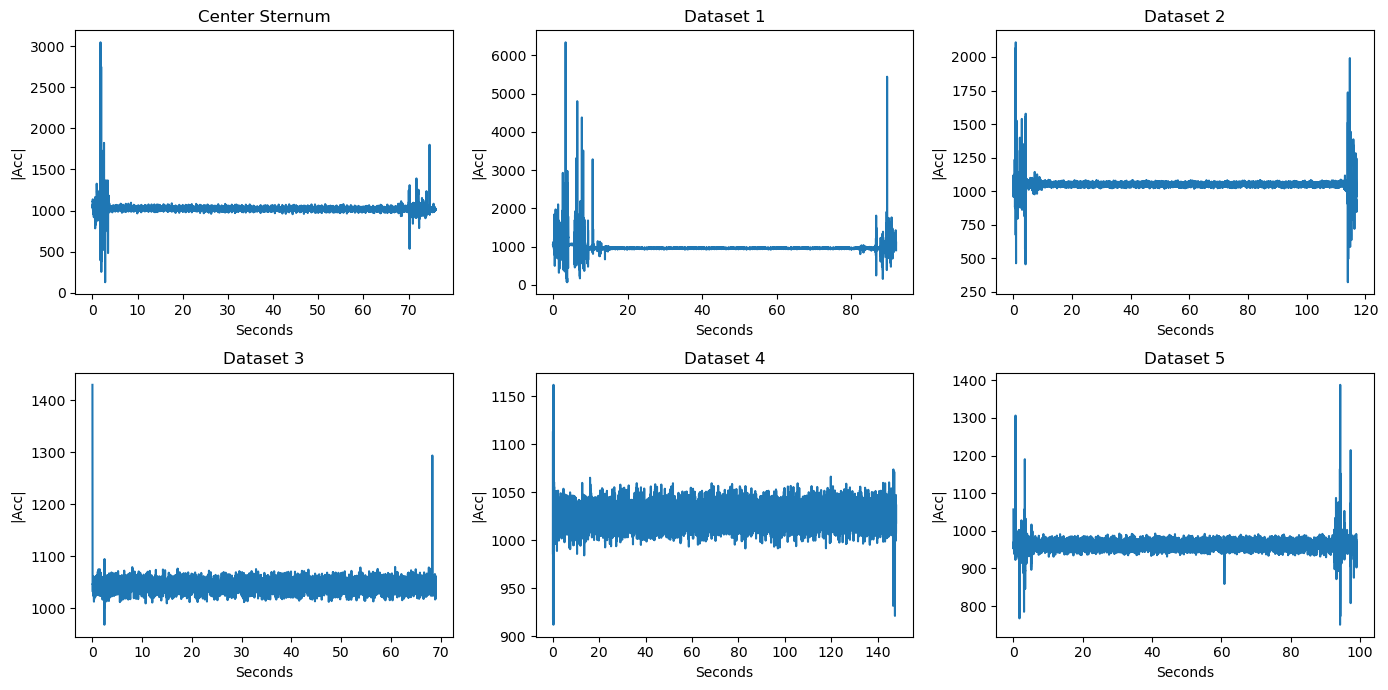

In [68]:
#ploting all of the acc magnitudes over time to compare the behavior
#cut to observe the 'middle' section over the datasets - removing the noise
#start = 0 
#end = 6500

all_datasets = [csternum] + [datasets[i] for i in range(1,6)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

titles = ['Center Sternum'] + [f'Dataset {i}' for i in range(1,6)]

for i, df in enumerate(all_datasets):

    #df_cut = df.iloc[start:end]
    
    axes[i].plot(df['Time'], df['MagAcc'])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Seconds')
    axes[i].set_ylabel('|Acc|')

plt.tight_layout()
plt.show()

Looking at the behavior of the Acceleration Magnitude: Dataset 1 has a lot of noise, indicating that the collected data is not very accurate and, furthermore, it would be necessary to remove a large part of the sample. The same is observed in Dataset 2, besides there's more data points
Dataset 5 presents a random peak, representing that maybe it can depend too much on the position of the person, which affects the quality of the data collected
For the Gyroscope magnitude: we can observe the same behavior

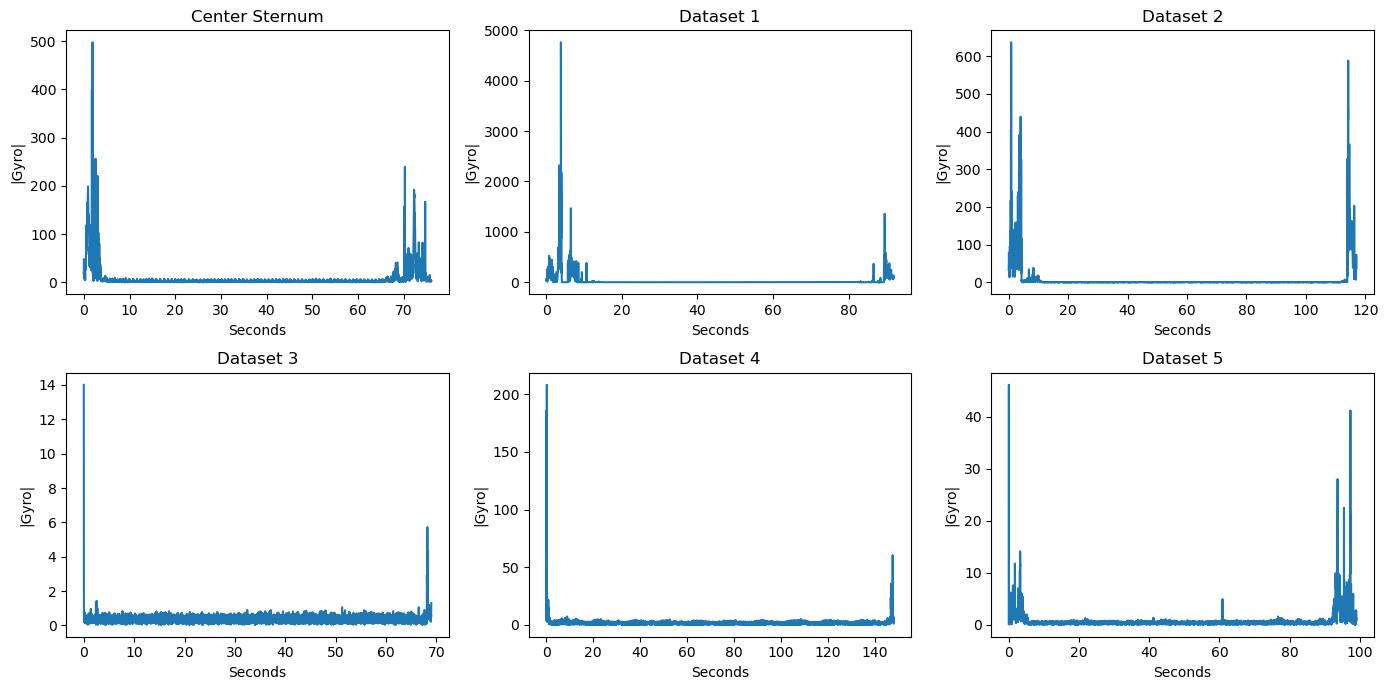

In [18]:
#ploting all of the gyro magnitudes over time to compare the behavior
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

titles = ['Center Sternum'] + [f'Dataset {i}' for i in range(1,6)]

for i, df in enumerate(all_datasets):
    
    axes[i].plot(df['Time'], df['MagGyro'])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Seconds')
    axes[i].set_ylabel('|Gyro|')

plt.tight_layout()
plt.show()

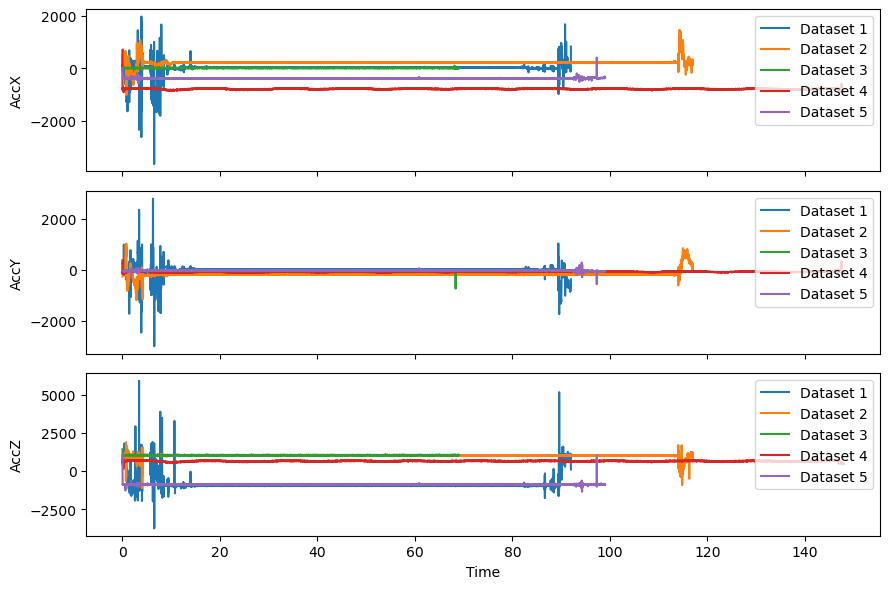

In [94]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)  # 3 linhas, 1 coluna, eixo X compartilhado

# AccX
axs[0].plot(datasets[1]['Time'], datasets[1]['AccX'], label='Dataset 1')
axs[0].plot(datasets[2]['Time'], datasets[2]['AccX'], label='Dataset 2')
axs[0].plot(datasets[3]['Time'], datasets[3]['AccX'], label='Dataset 3')
axs[0].plot(datasets[4]['Time'], datasets[4]['AccX'], label='Dataset 4')
axs[0].plot(datasets[5]['Time'], datasets[5]['AccX'], label='Dataset 5')
#axs[0].plot(csternum['Time'], csternum['AccX'], label='Center Sternum')
axs[0].set_ylabel('AccX')
axs[0].legend()

# AccY
axs[1].plot(datasets[1]['Time'], datasets[1]['AccY'], label='Dataset 1')
axs[1].plot(datasets[2]['Time'], datasets[2]['AccY'], label='Dataset 2')
axs[1].plot(datasets[3]['Time'], datasets[3]['AccY'], label='Dataset 3')
axs[1].plot(datasets[4]['Time'], datasets[4]['AccY'], label='Dataset 4')
axs[1].plot(datasets[5]['Time'], datasets[5]['AccY'], label='Dataset 5')
#axs[1].plot(csternum['Time'], csternum['AccY'], label='Center Sternum')
axs[1].set_ylabel('AccY')
axs[1].legend()

# AccZ
axs[2].plot(datasets[1]['Time'], datasets[1]['AccZ'], label='Dataset 1')
axs[2].plot(datasets[2]['Time'], datasets[2]['AccZ'], label='Dataset 2')
axs[2].plot(datasets[3]['Time'], datasets[3]['AccZ'], label='Dataset 3')
axs[2].plot(datasets[4]['Time'], datasets[4]['AccZ'], label='Dataset 4')
axs[2].plot(datasets[5]['Time'], datasets[5]['AccZ'], label='Dataset 5')
#axs[2].plot(csternum['Time'], csternum['AccZ'], label='Center Sternum')
axs[2].set_ylabel('AccZ')
axs[2].set_xlabel('Time')
axs[2].legend()

plt.tight_layout()  # Ajusta os subplots para não sobrepor
plt.show()

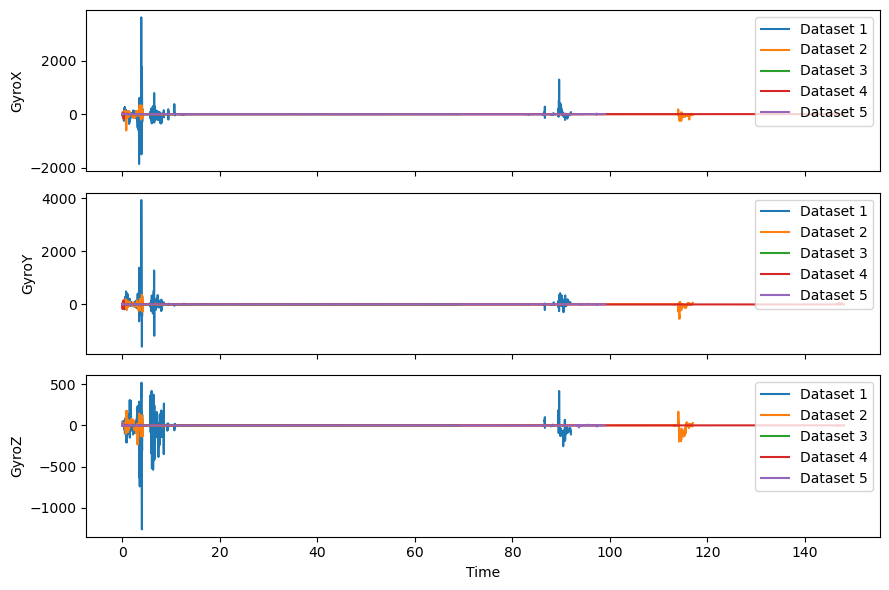

In [96]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)  # 3 linhas, 1 coluna, eixo X compartilhado

axs[0].plot(datasets[1]['Time'], datasets[1]['GyroX'], label='Dataset 1')
axs[0].plot(datasets[2]['Time'], datasets[2]['GyroX'], label='Dataset 2')
axs[0].plot(datasets[3]['Time'], datasets[3]['GyroX'], label='Dataset 3')
axs[0].plot(datasets[4]['Time'], datasets[4]['GyroX'], label='Dataset 4')
axs[0].plot(datasets[5]['Time'], datasets[5]['GyroX'], label='Dataset 5')
#axs[0].plot(csternum['Time'], csternum['GyroX'], label='Center Sternum')
axs[0].set_ylabel('GyroX')
axs[0].legend()

axs[1].plot(datasets[1]['Time'], datasets[1]['GyroY'], label='Dataset 1')
axs[1].plot(datasets[2]['Time'], datasets[2]['GyroY'], label='Dataset 2')
axs[1].plot(datasets[3]['Time'], datasets[3]['GyroY'], label='Dataset 3')
axs[1].plot(datasets[4]['Time'], datasets[4]['GyroY'], label='Dataset 4')
axs[1].plot(datasets[5]['Time'], datasets[5]['GyroY'], label='Dataset 5')
#axs[1].plot(csternum['Time'], csternum['GyroY'], label='Center Sternum')
axs[1].set_ylabel('GyroY')
axs[1].legend()

axs[2].plot(datasets[1]['Time'], datasets[1]['GyroZ'], label='Dataset 1')
axs[2].plot(datasets[2]['Time'], datasets[2]['GyroZ'], label='Dataset 2')
axs[2].plot(datasets[3]['Time'], datasets[3]['GyroZ'], label='Dataset 3')
axs[2].plot(datasets[4]['Time'], datasets[4]['GyroZ'], label='Dataset 4')
axs[2].plot(datasets[5]['Time'], datasets[5]['GyroZ'], label='Dataset 5')
#axs[2].plot(csternum['Time'], csternum['GyroZ'], label='Center Sternum')
axs[2].set_ylabel('GyroZ')
axs[2].set_xlabel('Time')
axs[2].legend()

plt.tight_layout()  # Ajusta os subplots para não sobrepor
plt.show()

In [90]:
#obtain all the std and see which one has the least
all_datasets = {'Center_sternum': csternum}

for i in range(1,6):
    all_datasets[f'Dataset_{i}'] = datasets[i]

results = []

for name, df in all_datasets.items():
    
    std_acc = df['MagAcc'].std()
    std_gyro = df['MagGyro'].std()
    mean_acc = df['MagAcc'].mean()
    mean_gyro = df['MagGyro'].mean()
    var_coef_acc = np.std(df['MagAcc']) / np.mean(df['MagAcc'])
    var_coef_gyro = np.std(df['MagGyro']) / np.mean(df['MagGyro'])
    
    results.append([name, std_acc, std_gyro, mean_acc, mean_gyro,var_coef_acc,var_coef_gyro])

df_comparison = pd.DataFrame(results,
                      columns=['Dataset','STD_MagAcc','STD_MagGyro','Mean_MagAcc','Mean_MagGyro','VarCoef_MagAcc','VarCoef_MagGyro'])

df_comparison

,Dataset,STD_MagAcc,STD_MagGyro,Mean_MagAcc,Mean_MagGyro,VarCoef_MagAcc,VarCoef_MagGyro
0,Center_sternum,44.675896,23.137800,1023.175769,7.423777,0.043663,3.116621
1,Dataset_1,166.956396,129.132253,974.505359,24.956908,0.171315,5.173927
2,Dataset_2,46.027480,34.919268,1052.476343,7.615617,0.043731,4.585023
3,Dataset_3,12.044059,0.280748,1043.348094,0.373181,0.011543,0.752258
4,Dataset_4,10.121403,4.686426,1025.737681,1.439932,0.009867,3.254508
5,Dataset_5,16.311223,1.601078,962.469683,0.725781,0.016946,2.205895


Dataset 1 and 2: they show a very high deviation, indicating the low accuracy of the data and much interference of noise

DS 3: data can be too smoothen, higher variation coefficient then 4

DS 5: shows peaks when data should be 'stable' = can depend too much on the position of the person

The dataset 4 shows the smaller STD in acceleration, while still showing a good std in gyroscope - should justify our choice
(here can be good to instert the papers data about choosing datset 4 -> position to the heart etc

In [98]:
#STATISTICAL ANALYSIS
datasets[4].describe()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk,Time,MagAcc,MagGyro
count,14938.0,14938.0,1.493800e+04,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000,14938.000000
mean,5.0,100.0,1.555415e+09,-789.546594,-77.535226,649.196874,-0.013451,-0.191934,-0.053633,116.943634,42.895702,-125.815035,0.045135,-0.334707,-0.001663,0.673555,73.995046,1025.737681,1.439932
std,0.0,0.0,4.958891e+01,20.878583,15.687155,26.574433,2.073793,4.413089,0.469316,7.876135,4.863274,8.787037,0.031411,0.293897,0.017825,0.587030,42.725350,10.121403,4.686426
min,5.0,100.0,1.555415e+09,-914.692632,-183.888353,265.781219,-169.390701,-176.427305,-10.585071,-592.000000,29.000000,-159.000000,0.001505,-0.487381,-0.432874,-0.907834,0.000000,912.151358,0.043786
25%,5.0,100.0,1.555415e+09,-798.849336,-86.776031,635.917352,-0.488284,-0.939446,-0.219220,113.000000,39.000000,-131.000000,0.013244,-0.449538,-0.013245,0.887417,36.997523,1019.834694,0.623971
50%,5.0,100.0,1.555415e+09,-787.025728,-77.126559,652.962439,-0.000479,-0.329690,-0.097268,116.000000,43.000000,-127.000000,0.042618,-0.440352,-0.002686,0.894253,73.995046,1025.799921,0.970785
75%,5.0,100.0,1.555415e+09,-778.663944,-66.960045,666.109535,0.487326,0.402017,0.146634,120.000000,46.000000,-122.000000,0.072328,-0.434706,0.008454,0.897549,110.992569,1031.713309,1.508357
max,5.0,100.0,1.555415e+09,688.816190,377.479431,771.826188,47.438549,152.962995,22.707609,146.000000,122.000000,-50.000000,0.788006,0.535050,0.043733,0.902310,147.990092,1161.622890,208.175169


In [112]:
datasets[4].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14938 entries, 0 to 14937
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Log Mode   14938 non-null  int64  
 1   Log Freq   14938 non-null  int64  
 2   Timestamp  14938 non-null  int64  
 3   AccX       14938 non-null  float64
 4   AccY       14938 non-null  float64
 5   AccZ       14938 non-null  float64
 6   GyroX      14938 non-null  float64
 7   GyroY      14938 non-null  float64
 8   GyroZ      14938 non-null  float64
 9   MagnX      14938 non-null  int64  
 10  MagnY      14938 non-null  int64  
 11  MagnZ      14938 non-null  int64  
 12  qw         14938 non-null  float64
 13  qi         14938 non-null  float64
 14  qj         14938 non-null  float64
 15  qk         14938 non-null  float64
 16  Time       14938 non-null  float64
 17  MagAcc     14938 non-null  float64
 18  MagGyro    14938 non-null  float64
dtypes: float64(13), int64(6)
memory usage: 2.2 MB


In [118]:
pip install --upgrade seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ----- ---------------------------------- 41.0/294.9 kB 85.6 kB/s eta 0:00:03
   ----- ---------------------------------- 41.0/294.9 kB 85.6 kB/s eta 0:00:03
   ----- ---------------------------------- 41.0/294.9 kB 85.6 kB/s eta 0:00:03
   ----- ---------------------------------- 41.0/294.9 kB 85.6 kB/s eta 0:00:03
   ----- ---------------------------------- 41.0/294.9 kB 85.6 kB/s eta 0:00:03
   -------- -------------

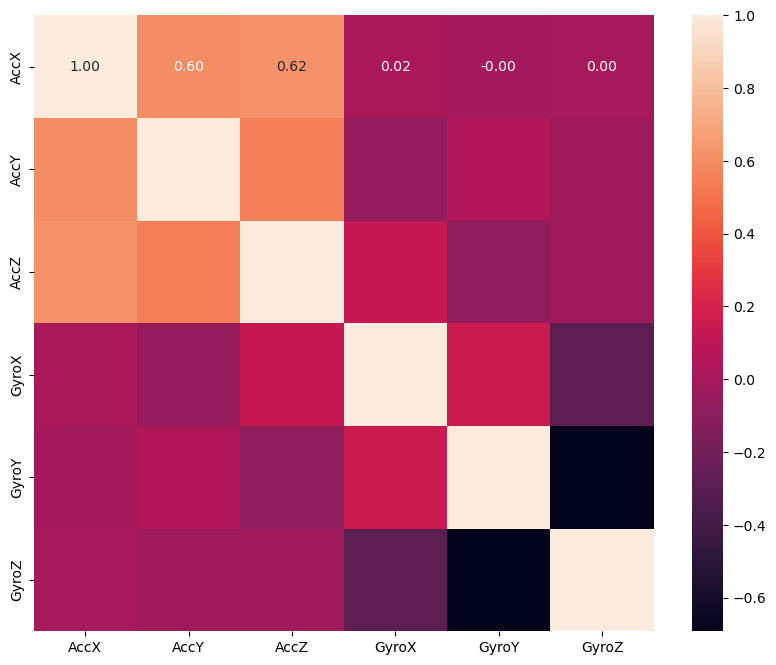

In [120]:
#correlation matrix of the 4 dataset 
cols = ['AccX','AccY',	'AccZ',	'GyroX',	'GyroY',	'GyroZ']
        #,	'MagnX',	'MagnY',	'MagnZ',	'qw',	'qi',	'qj',	'qk']
corr_matrix = datasets[4][cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',cmap="rocket",annot_kws={"size":10})
plt.show()

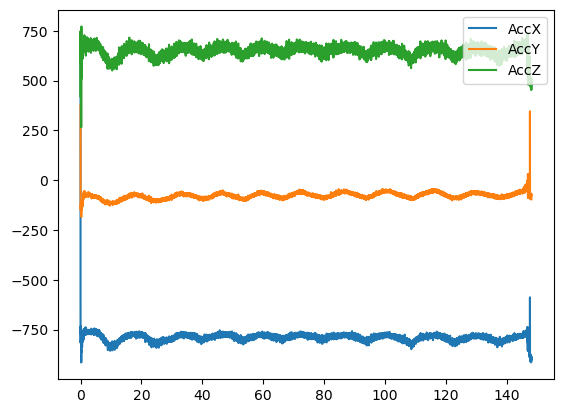

In [144]:
#Behavion of acc of chest sweater over time
plt.plot(datasets[4]['Time'], datasets[4]['AccX'], label='AccX')
plt.plot(datasets[4]['Time'], datasets[4]['AccY'], label='AccY')
plt.plot(datasets[4]['Time'], datasets[4]['AccZ'], label='AccZ')
#plt.plot(datasets[4]['Time'], datasets[4]['MagAcc'], label='|Acc|')
plt.legend()

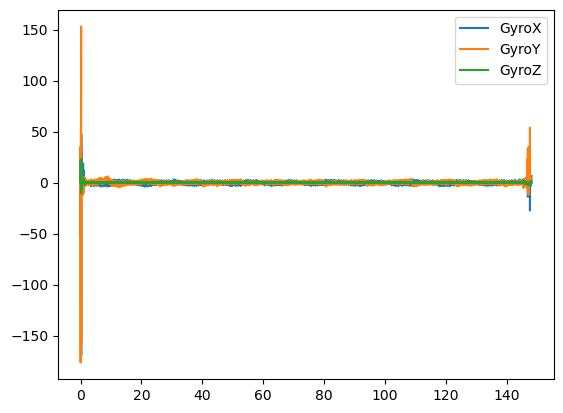

In [150]:
#Behavion of gyroscope of chest sweater over time
plt.plot(datasets[4]['Time'], datasets[4]['GyroX'], label='GyroX')
plt.plot(datasets[4]['Time'], datasets[4]['GyroY'], label='GyroY')
plt.plot(datasets[4]['Time'], datasets[4]['GyroZ'], label='GyroZ')
#plt.plot(datasets[4]['Time'], datasets[4]['MagGyro'], label='|Gyro|')
plt.legend()

### MY studies on fft (not finished)

In [153]:
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq

fs = counts_ds.mean()   # ajuste se necessário

# juntar todos os datasets
for i in range(1,6):
    all_datasets[f'Dataset_{i}'] = datasets[i]

results = []

for name, df in all_datasets.items():
    
    signal = df['MagAcc'].values
    
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)
    
    # pegar apenas frequências positivas
    xf = xf[:N//2]
    yf = np.abs(yf[:N//2])
    
    # banda cardíaca
    heart_band = (xf >= 0.8) & (xf <= 2.5)
    
    # potência na banda cardíaca
    power_heart = np.sum(yf[heart_band]**2)
    
    # potência fora da banda
    power_total = np.sum(yf**2)
    power_noise = power_total - power_heart
    
    # SNR
    snr = power_heart / power_noise
    
    # pico dominante na banda
    peak_freq = xf[heart_band][np.argmax(yf[heart_band])]
    bpm = peak_freq * 60
    
    results.append([name, power_heart, snr, peak_freq, bpm])

# criar dataframe comparativo
comparison = pd.DataFrame(results, 
                           columns=['Dataset', 
                                    'Power_HeartBand', 
                                    'SNR', 
                                    'Peak_Freq_Hz', 
                                    'Estimated_BPM'])

comparison.sort_values(by='SNR', ascending=False)

,Dataset,Power_HeartBand,SNR,Peak_Freq_Hz,Estimated_BPM
1,Dataset_1,1.508604e+11,0.001865,2.347444,140.846634
2,Dataset_2,2.363547e+10,0.000155,1.866724,112.003467
0,Center_sternum,2.097044e+10,0.000073,1.643817,98.629038
5,Dataset_5,8.614116e+08,0.000009,1.505051,90.303030
3,Dataset_3,7.067941e+07,0.000001,0.960223,57.613409
4,Dataset_4,2.648876e+08,0.000001,0.938343,56.300588


In [155]:
fs = counts_cs.mean()   # ajuste se necessário
signal = csternum['MagAcc'].values #O FS É DIFERENTE, NÃO CONSIDERAR AQUI
    
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1/fs)

teste_re = []
    # pegar apenas frequências positivas
xf = xf[:N//2]
yf = np.abs(yf[:N//2])
    
    # banda cardíaca
heart_band = (xf >= 0.8) & (xf <= 2.5)
    
    # potência na banda cardíaca
power_heart = np.sum(yf[heart_band]**2)
    
    # potência fora da banda
power_total = np.sum(yf**2)
power_noise = power_total - power_heart
    
    # SNR
snr = power_heart / power_noise
    
    # pico dominante na banda
peak_freq = xf[heart_band][np.argmax(yf[heart_band])]
bpm = peak_freq * 60
    
teste_re.append([name, power_heart, snr, peak_freq, bpm])

teste_re = pd.DataFrame(results, 
                           columns=['Dataset', 
                                    'Power_HeartBand', 
                                    'SNR', 
                                    'Peak_Freq_Hz', 
                                    'Estimated_BPM'])
teste_re

,Dataset,Power_HeartBand,SNR,Peak_Freq_Hz,Estimated_BPM
0,Center_sternum,2.097044e+10,0.000073,1.643817,98.629038
1,Dataset_1,1.508604e+11,0.001865,2.347444,140.846634
2,Dataset_2,2.363547e+10,0.000155,1.866724,112.003467
3,Dataset_3,7.067941e+07,0.000001,0.960223,57.613409
4,Dataset_4,2.648876e+08,0.000001,0.938343,56.300588
5,Dataset_5,8.614116e+08,0.000009,1.505051,90.303030


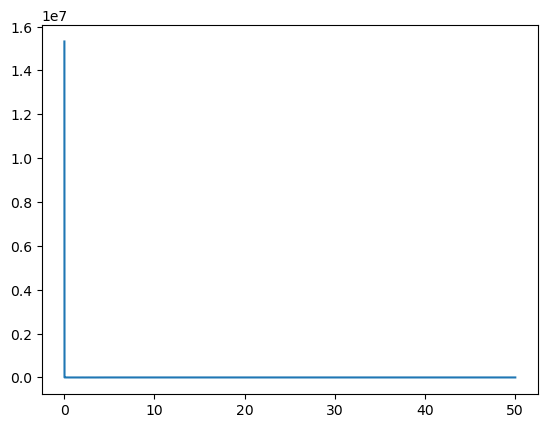

In [157]:
from scipy.fft import fft, fftfreq

fs = counts_ds.mean()  # ou 200 dependendo do dataset
signal = datasets[4]['MagAcc'].values

N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1/fs)

# considerar apenas frequências positivas
xf = xf[:N//2]
yf = np.abs(yf[:N//2])

plt.plot(xf, yf)